In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import pickle

In [2]:
# Load Dataset

df = pd.read_csv("tmdb_5000_movies.csv")

df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [3]:
# Basic Exploration

print(df.shape)

print(df.info())

print(df.isnull().sum())

(4803, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status    

In [6]:
# Select Important Features

features = [
    'genres',
    'keywords',
    'overview',
    'title'
]

movies = df[features].copy()

In [7]:
# Handle Missing Values

for feature in features:
    movies[feature] = movies[feature].fillna('')

In [8]:
# Create Combined Text Feature

movies['tags'] = (
    movies['genres']
    + ' '
    + movies['keywords']
    + ' '
    + movies['overview']
)

In [9]:
# Convert Text to Vectors

cv = CountVectorizer(
    max_features=5000,
    stop_words='english'
)

vectors = cv.fit_transform(
    movies['tags']
).toarray()

In [10]:
# Compute Cosine Similarity

similarity = cosine_similarity(
    vectors
)

In [11]:
# Recommendation Function

def recommend(movie):

    movie_index = movies[
        movies['title'] == movie
    ].index[0]

    distances = similarity[
        movie_index
    ]

    movie_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:6]

    for i in movie_list:
        print(
            movies.iloc[
                i[0]
            ].title
        )

In [12]:
# Test Recommendations

recommend("Avatar")

The Fifth Element
Dune
Interstellar
Southland Tales
Everyone Says I Love You


In [13]:
# Most Popular Movies

top_movies = df.sort_values(
    by='vote_average',
    ascending=False
).head(10)

top_movies[
    ['title','vote_average']
]

,title,vote_average
4662,Little Big Top,10.0
3519,Stiff Upper Lips,10.0
4045,"Dancer, Texas Pop. 81",10.0
4247,Me You and Five Bucks,10.0
3992,Sardaarji,9.5
2386,One Man's Hero,9.3
1881,The Shawshank Redemption,8.5
2970,There Goes My Baby,8.5
3337,The Godfather,8.4
2796,The Prisoner of Zenda,8.4


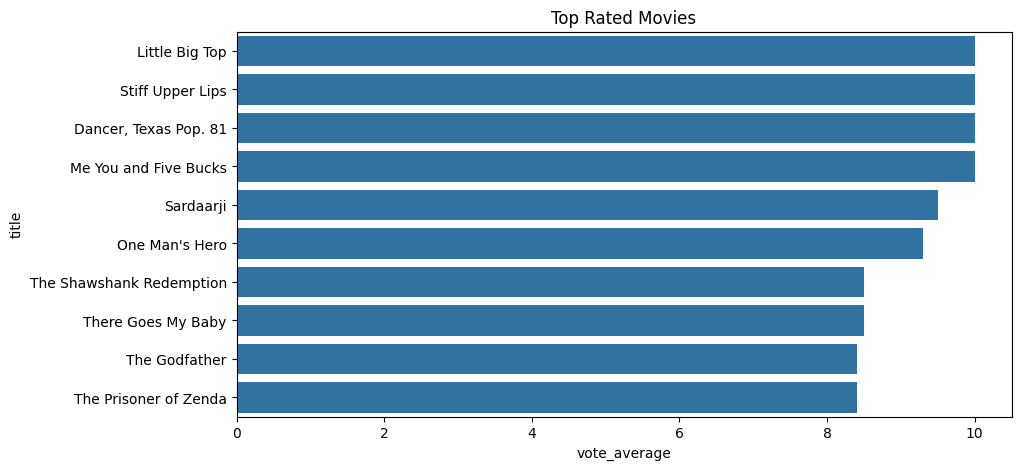

In [14]:
# Vizualize Top Movies

top_movies = top_movies.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x='vote_average',
    y='title',
    data=top_movies
)

plt.title(
    'Top Rated Movies'
)

plt.show()

In [15]:
# Save Recommender

pickle.dump(
    movies,
    open(
        'movie_recommender.pkl',
        'wb'
    )
)

In [16]:
# Sample Queries

recommend("Batman Begins")

Everyone Says I Love You
Brooklyn's Finest
The Dark Knight
The Dark Knight Rises
Southland Tales


In [17]:
recommend("The Dark Knight")

Batman Begins
The Dark Knight Rises
Batman Forever
Brooklyn's Finest
Everyone Says I Love You


In [18]:
recommend("Spider-Man")

Spider-Man 3
Everyone Says I Love You
Fantastic 4: Rise of the Silver Surfer
Mystery Men
Brooklyn's Finest
